# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [1]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset
# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...
import re
import nltk
import numpy as np
from nltk.corpus import stopwords
from urllib.parse import urlparse
from IPython.display import display
from data_profiling import ProfileReport

sns.set_theme(
    palette="deep",
    context="notebook",
    font_scale=1.1
    )

figures_path = Path('informe/figures')

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [2]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [3]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,None,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,None,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,None,Vox


In [4]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idx          30213 non-null  int64 
 1   article_idx  30213 non-null  int64 
 2   date         30213 non-null  object
 3   year         30213 non-null  object
 4   month        30213 non-null  object
 5   day          30213 non-null  object
 6   author       18808 non-null  object
 7   title        30213 non-null  object
 8   article      29037 non-null  object
 9   url          30072 non-null  object
 10  section      19981 non-null  object
 11  publication  30072 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.8+ MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

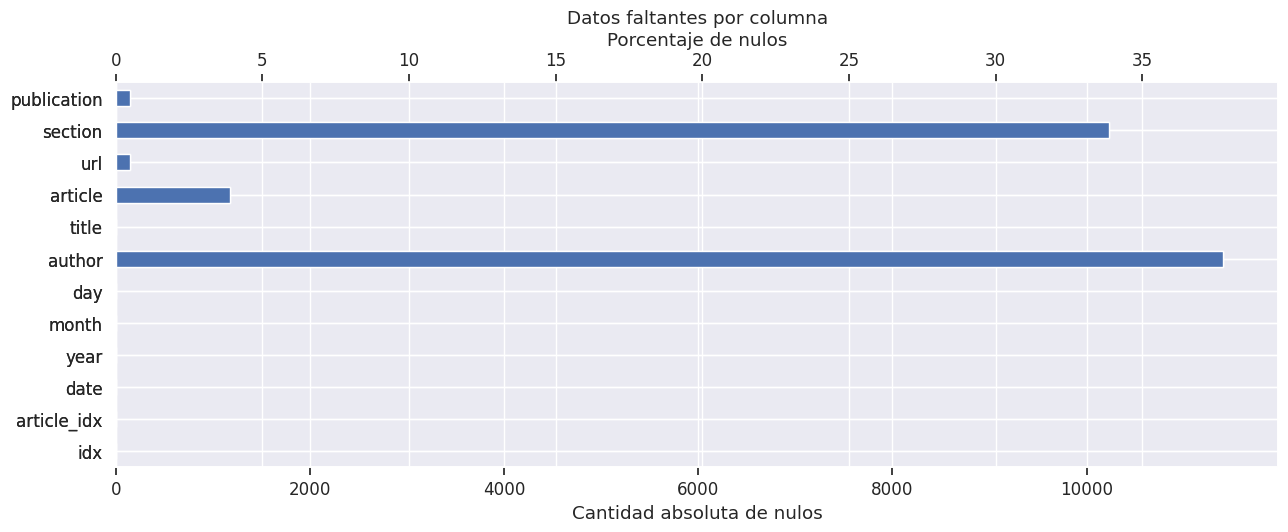

idx             0.000000
article_idx     0.000000
date            0.000000
year            0.000000
month           0.000000
day             0.000000
author         37.748651
title           0.000000
article         3.892364
url             0.466687
section        33.866217
publication     0.466687
dtype: float64


In [5]:
# TODO: Analice datos faltantes por columna
num_nulls = df.isnull().sum()
pct_null = 100 * num_nulls / len(df)

plt.figure(figsize=(15, 5))
plt.title('Datos faltantes por columna')
ax1 = num_nulls.plot(kind='barh', xlabel='Cantidad absoluta de nulos')
ax2 = ax1.twiny()
ax2 = pct_null.plot(kind='barh', xlabel='Porcentaje de nulos')
plt.savefig(figures_path / 'nulls.png')
plt.show()

print(pct_null)

In [6]:
profile = ProfileReport(
    df, 
    minimal=False, 
    vars={"text": {"words": False, "characters": False}}
)

profile.to_file('report.html')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 15.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Top 5 publications: ['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People']


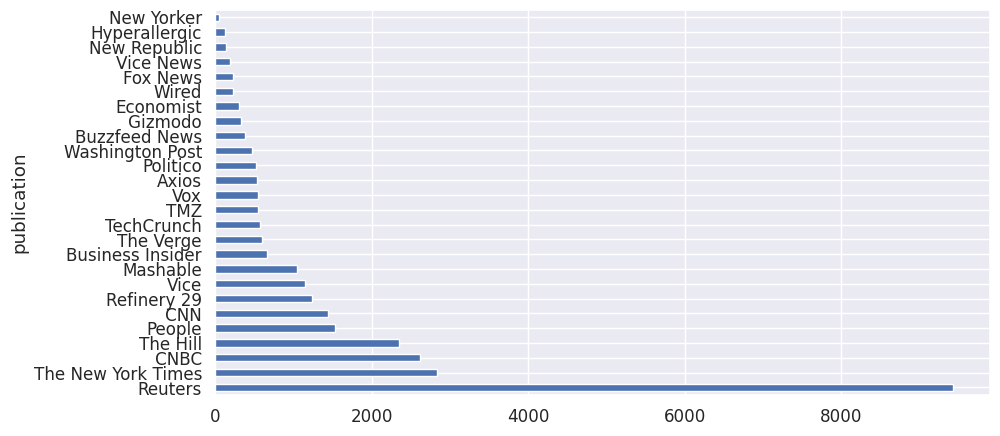

<Figure size 1500x500 with 0 Axes>

publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
Name: count, dtype: int64

publication
Fox News         227
Vice News        187
New Republic     145
Hyperallergic    123
New Yorker        52
Name: count, dtype: int64

In [7]:
# TODO: Analice la cantidad de artículos por medio de prensa

# Tome los 5 medios con más artículos
# top_5_publications = ...
# df_top_5 = ...

count_by_publication = df['publication'].value_counts()
count_by_publication.plot(kind='barh', figsize=(10, 5))
top_5 = count_by_publication[:5].index.values
df_top_5 = df[df['publication'].isin(top_5)]
print(f'Top 5 publications: {top_5.tolist()}')
plt.figure(figsize=(15, 5))
plt.savefig(figures_path / 'count_by_publication.png')
plt.show()
display(count_by_publication.head())
display(count_by_publication.tail())

## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

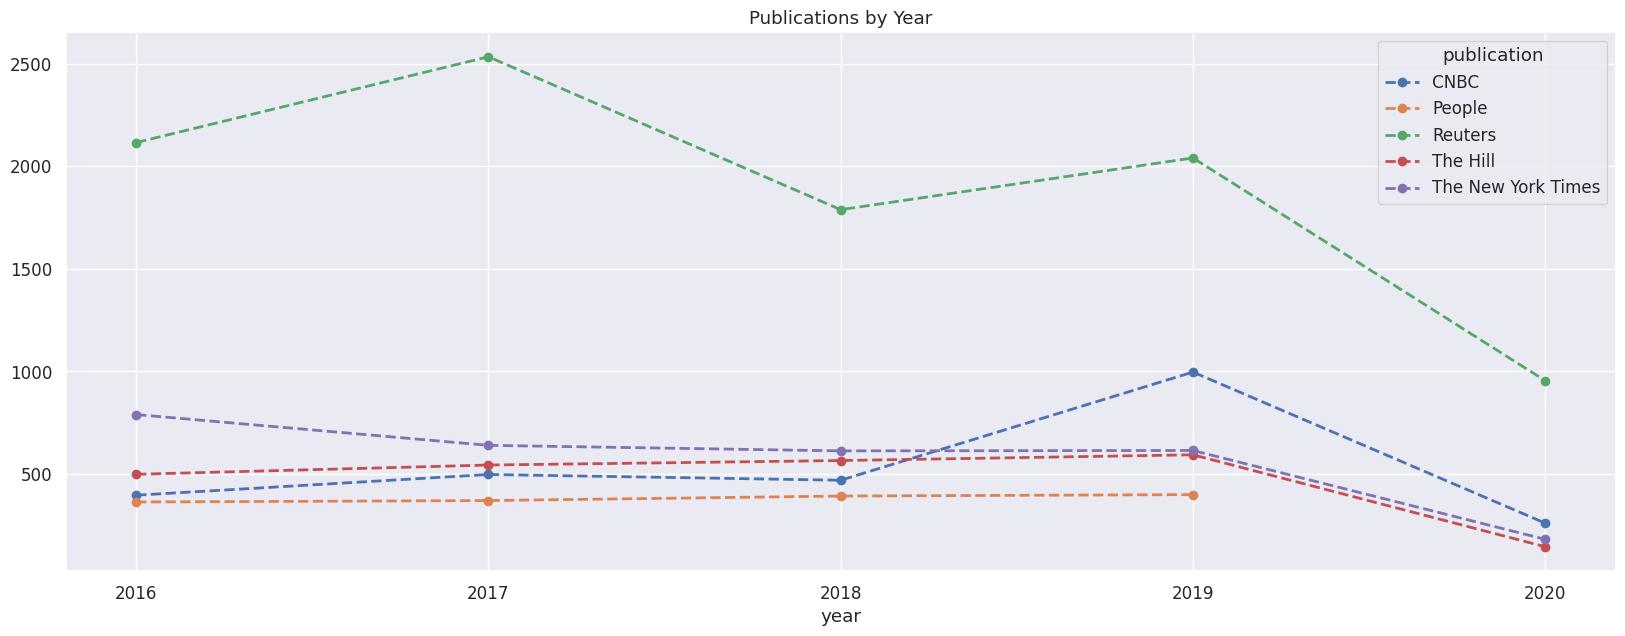

/tmp/ipykernel_23838/3492383997.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5.loc[:, 'clean_date'] = pd.to_datetime(df_top_5[['year', 'month', 'day']])
/tmp/ipykernel_23838/3492383997.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5.loc[:, 'date_month'] = df_top_5['clean_date'].dt.to_period('M').astype(str)


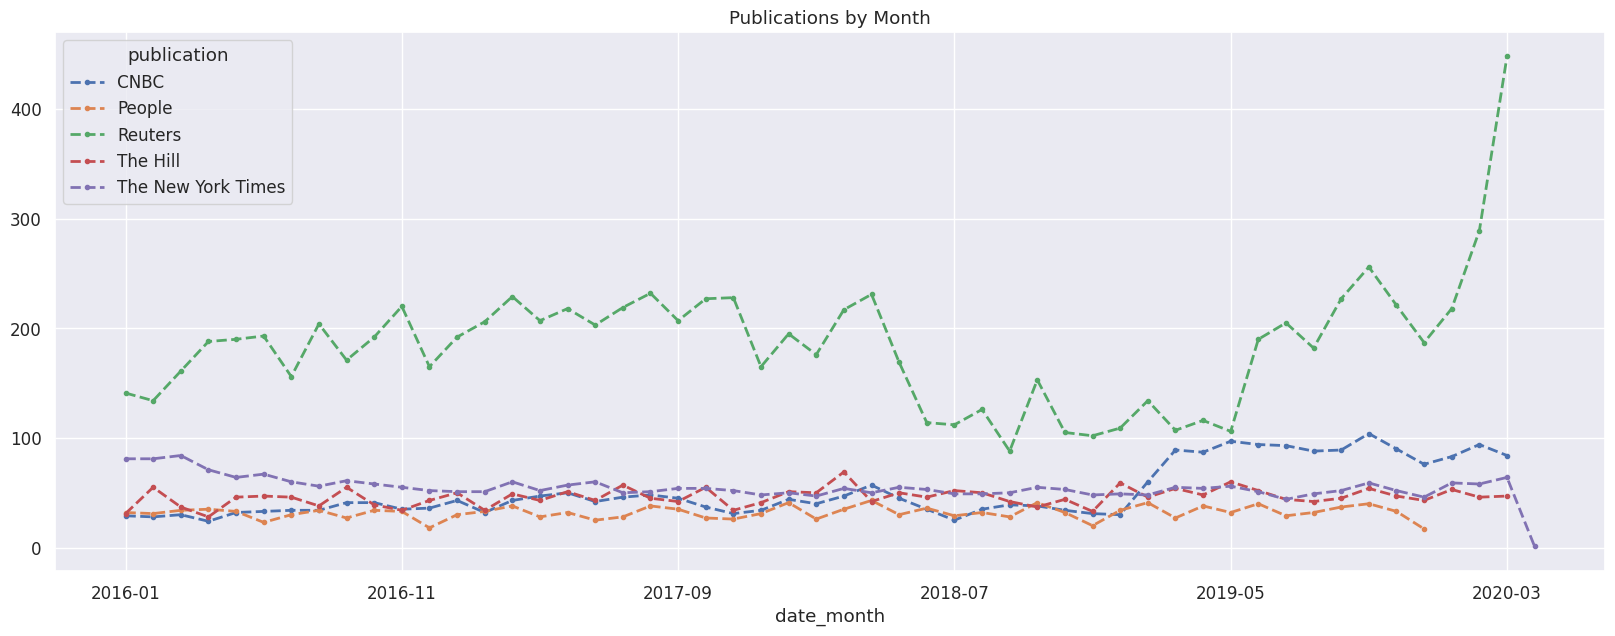

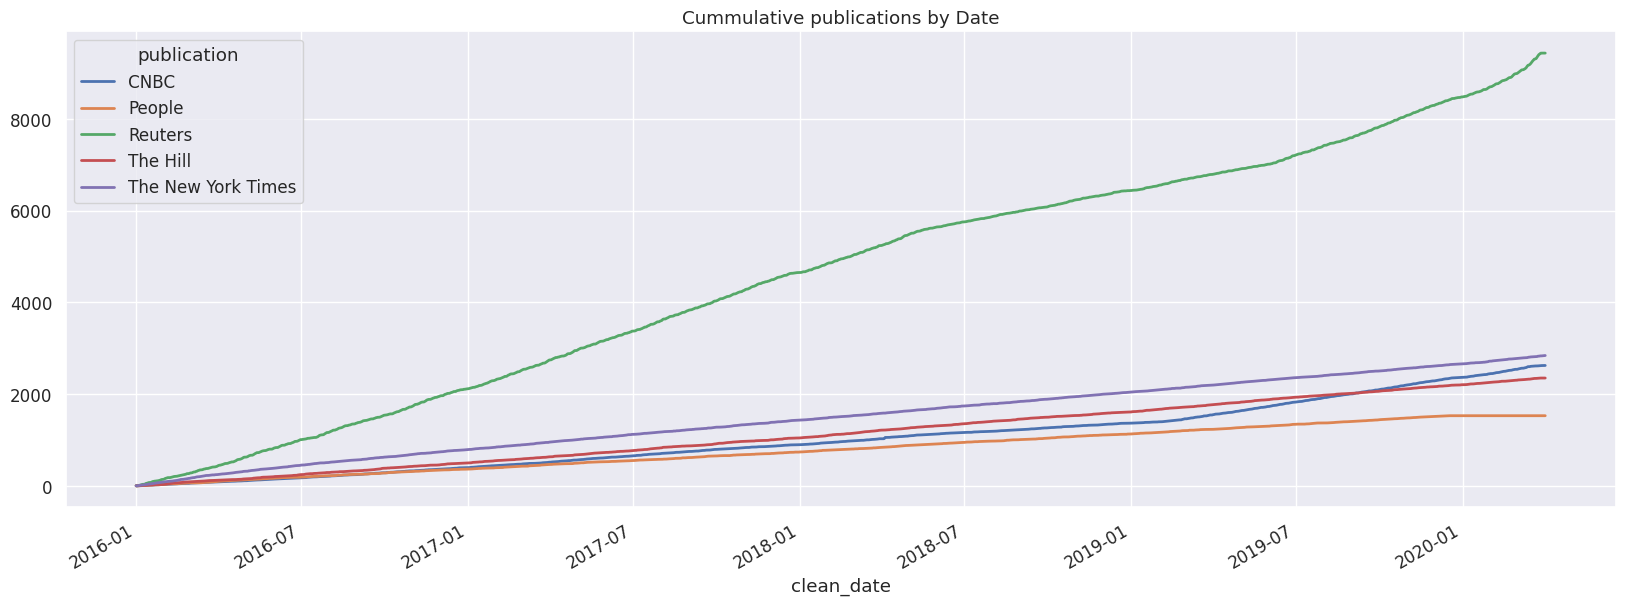

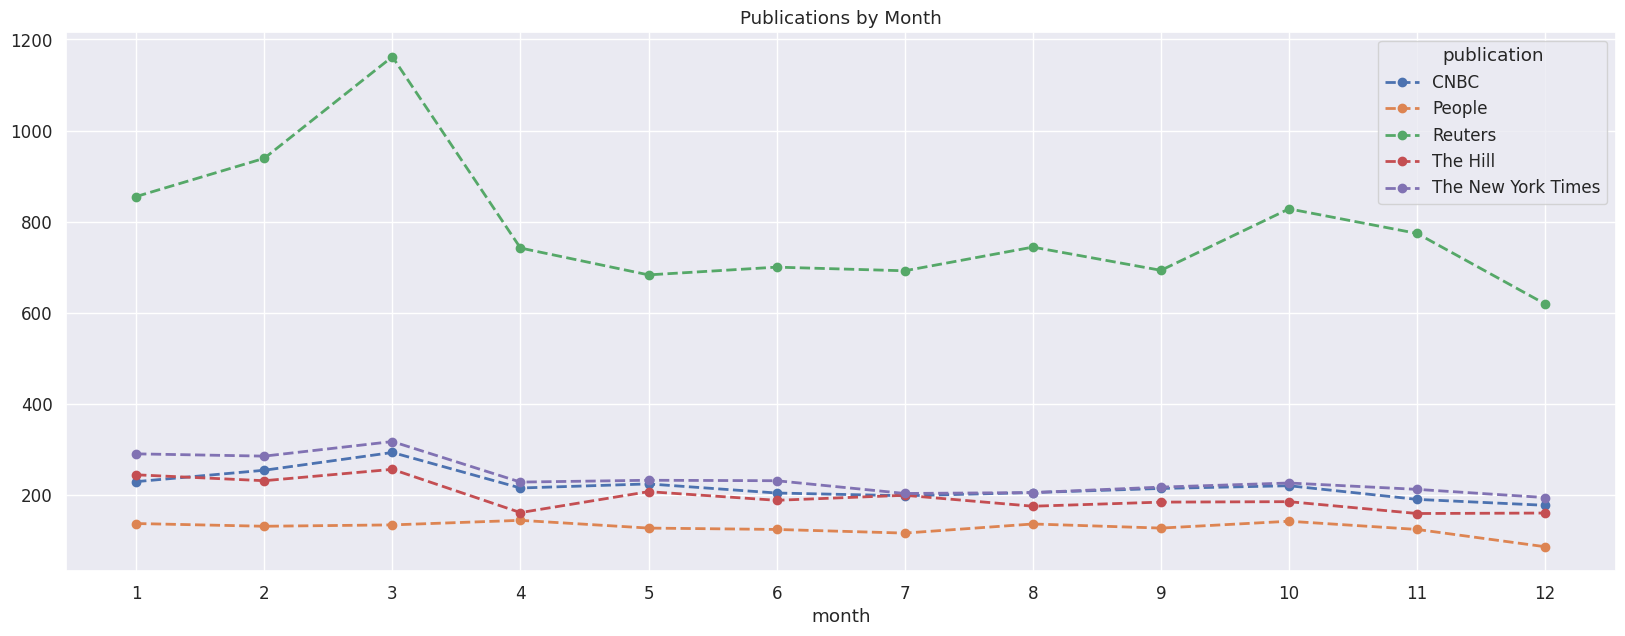

In [8]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo
# Preste especial atención al formato de la columna 'date', ya que puede contener diferentes formatos de fecha.

# Get a clean date
df_top_5.loc[:, 'year'] = df_top_5['year'].apply(lambda x: int(x))
df_top_5.loc[:, 'month'] = df_top_5['month'].apply(lambda x: int(float(x)))
assert df_top_5['month'].isin(range(1, 13, 1)).all(), f'Found at least one invalid month: {sorted(df_top_5["month"].unique())}'
df_top_5.loc[:, 'day'] = df_top_5['day'].apply(lambda x: int(x))
assert df_top_5['day'].isin(range(1, 32, 1)).all(), f'Found at least one invalid day: {sorted(df_top_5["day"].unique())}'

def get_counts(df: pd.DataFrame, col_name: str, groupby_col='publication') -> pd.DataFrame:
    df_counts = df.groupby(groupby_col).value_counts([col_name]).reset_index()
    df_counts = df_counts.pivot(index=col_name, columns=groupby_col, values='count')
    return df_counts

def plot_by_col(df: pd.DataFrame, col_name: str, name: str, title: str = '', groupby_col='publication', line='-', xticks=None) -> pd.DataFrame:
    df_counts = get_counts(df, col_name, groupby_col)
    df_counts.plot(
        figsize=(20, 7),
        title=title,
        kind='line', 
        xticks=xticks, 
        style=line,
        linewidth=2
        )
    plt.savefig(figures_path / name)
    plt.show()
    return df_counts

def plot_by_col_cummulative(df_counts: pd.DataFrame, name: str, title: str = '', line='--o', xticks=None) -> None:
    # cummulative year
    df_counts_cummulative = df_counts.sort_index().fillna(0).cumsum()
    df_counts_cummulative.plot(
        figsize=(20, 7),
        title=title,
        kind='line', 
        xticks=xticks, 
        style=line,
        linewidth=2
        )
    plt.savefig(figures_path / name)
    plt.show()

# Plot by year
years = df_top_5['year'].unique().astype(int).tolist()
df_counts_per_year = plot_by_col(df_top_5, 'year', name='publications_by_year.png', title='Publications by Year', line='--o', xticks=years)



# plot by month
df_top_5.loc[:, 'clean_date'] = pd.to_datetime(df_top_5[['year', 'month', 'day']])
df_top_5.loc[:, 'date_month'] = df_top_5['clean_date'].dt.to_period('M').astype(str)
xticks = df_top_5['date_month'].unique()
plot_by_col(df_top_5, 'date_month', name='publications_by_month.png', title='Publications by Month', line='--.', xticks=None)


# plot by date
assert df_top_5['clean_date'].isna().sum() == 0, 'Found dates with null values'
plot_by_col_cummulative(
    get_counts(df_top_5, 'clean_date'), 
    name='cummulative_publications_by_date.png', title='Cummulative publications by Date', line='-')

# Plot by month
months = df_top_5['month'].unique().astype(int).tolist()
df_counts_per_month = plot_by_col(df_top_5, 'month', name='publications_by_months.png', title='Publications by Month', line='--o', xticks=months)



## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [9]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # TODO: completar signos de puntuación faltantes
    for punc in ["[", "\n", ",", ":", "?", "(", ")", "!", ".", "'", "\"", "’", "‘", "/", "“", "”", "]", "-", "#", ";", "xa0", "\xa0", "\x7f"]:
        result = result.str.replace(punc, " ")

    result.fillna("", inplace=True)

    return result

In [10]:
# TODO: Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"

df_top_5.loc[:, 'title_clean_text'] = clean_text(df_top_5, 'title')
df_top_5.loc[:, 'article_clean_text'] = clean_text(df_top_5, 'article')

sample_words = []
for i, ind in enumerate(np.random.randint(0, len(df_top_5), 20)):
    row = df_top_5.iloc[ind]
    title = row['title_clean_text']
    if title:
        sample_words.extend(title.split(' '))
    article = row['article_clean_text']
    if article:
        sample_words.extend(article.split(' '))
    if i < 5:
        row = df_top_5.iloc[ind]
        print('='*20)
        print(f"Title: {repr(row['title'])}")
        print(f"Clean Title: {repr(row['title_clean_text'])}\n")
        print(f"Article: {repr(row['article'][:100])}")
        print(f"Clean Article: {repr(row['article_clean_text'][:100])}")

print('='*20)
# print(np.unique(sample_words).tolist())
print('Random sample of non-alphanumeric words:')
print(np.unique([w for w in sample_words if not w.isalnum()]).tolist())



/tmp/ipykernel_23838/3297954738.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5.loc[:, 'title_clean_text'] = clean_text(df_top_5, 'title')


Title: "Cramer's game plan: Crucial event to create market fireworks next week"
Clean Title: 'cramer s game plan  crucial event to create market fireworks next week'

Article: "In Jim Cramer's perspective, this week was a harsh reminder to investors that panic is not an invest"
Clean Article: 'in jim cramer s perspective  this week was a harsh reminder to investors that panic is not an invest'
Title: 'Steven Cohen, SAC must again face Fairfax short-selling lawsuit'
Clean Title: 'steven cohen  sac must again face fairfax short selling lawsuit'

Article: 'April 27 (Reuters) - The billionaire Steven A. Cohen must again face a lawsuit accusing him and his '
Clean Article: 'april 27  reuters    the billionaire steven a  cohen must again face a lawsuit accusing him and his '
Title: 'Indians grind out win vs. Twins'
Clean Title: 'indians grind out win vs  twins'

Article: 'Indians grind out win vs. Twins MINNEAPOLIS — It wasn’t pretty for the Cleveland Indians on Wednesda'
Clean Article: 'ind

/tmp/ipykernel_23838/3297954738.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5.loc[:, 'article_clean_text'] = clean_text(df_top_5, 'article')


## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

*TODO: Escriba su análisis en el informe.*

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [11]:
# TODO: Explore el texto buscando pistas que identifiquen directamente al medio de prensa
# Por ejemplo, busque nombres de medios, URLs, firmas, etc.

N = 250
for publication, p_group in df_top_5.groupby('publication'):
    print(f'Publication: {publication}')
    all_tags, all_urls = [], []
    all_publication_mentions = []
    start_samples, ending_samples = [], []
    for i in np.random.randint(0, len(p_group), (10,)):
        row = p_group.iloc[i]
        article = row['article_clean_text']
        start_samples.append(article[:min(N, len(article))])
        ending_samples.append(article[-min(N, len(article)):])
    print('    Sample starts:')
    for i, sample in enumerate(start_samples):
        print(f'     {i} - {repr(sample)}')
    print('    Sample endings:')
    for i, sample in enumerate(ending_samples):
        print(f'     {i} - {repr(sample)}')

Publication: CNBC
    Sample starts:
     0 - 'apple stock closed at a record friday  surpassing its previous high of $183 50 — pushed up by news that warren buffett s berkshire hathaway bought 75 million shares in the first quarter  the stock closed at $183 83  and is now roughly $20 per share s'
     1 - 'oracle s openworld conference  one of the biggest annual technology events in san francisco  is moving to las vegas in 2020 and will remain in sin city for at least three years  according to an email that the san francisco travel association  sfta  s'
     2 - 'as stocks sold off on wednesday  cnbc s jim cramer noticed a disturbing pattern occurring in the market   the wrong stocks are going up   the  mad money   host warned   the universe of winners has gotten incredibly small   cramer could count the winn'
     3 - 'once again  house republicans have offered what they consider explosive evidence of malfeasance by top government officials — this time  at the justice department and 

/tmp/ipykernel_23838/105381323.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  num_matches = p_group['article_clean_text'].str.contains(pattern, regex=True).sum()


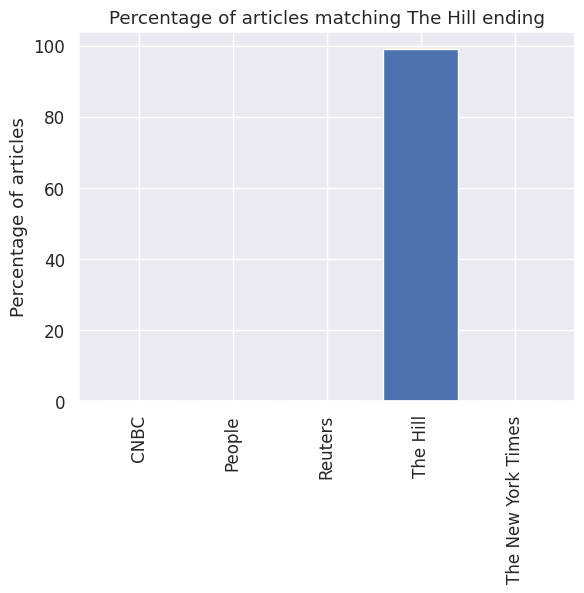

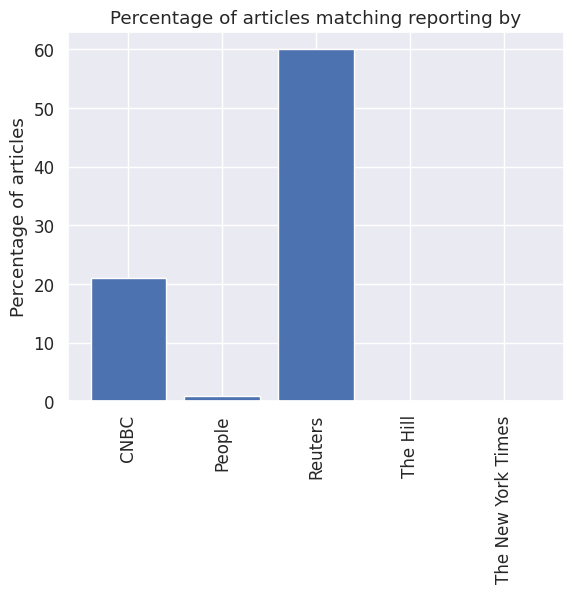

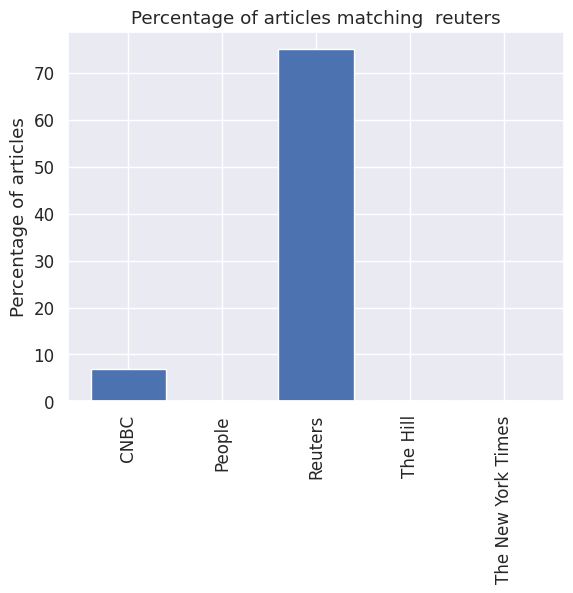

In [12]:
def visualize_matches(pattern: re.Pattern, df: pd.DataFrame, pattern_name: str) -> None:
    publications, matches, matches_pct = [], [], []
    for publication, p_group in df.groupby('publication'):
        num_matches = p_group['article_clean_text'].str.contains(pattern, regex=True).sum()
        publications.append(publication)
        matches.append(num_matches)
        matches_pct.append(int(100*num_matches / len(p_group)))
    plt.bar(publications, matches_pct)
    plt.title(f'Percentage of articles matching {pattern_name}')
    plt.ylabel('Percentage of articles')
    plt.xticks(rotation=90)
    plt.show()

pattern = re.compile(r'(view the discussion thread  )?the hill 1625 k street  nw suite 900.*')
visualize_matches(pattern, df_top_5, 'The Hill ending')

pattern = re.compile(r'reporting by.*')
visualize_matches(pattern, df_top_5, 'reporting by')

pattern = re.compile(r'^[a-z\s\d]{5,30}reuters')
visualize_matches(pattern, df_top_5, ' reuters')

In [13]:


def print_mentions(mentions: list, total: int, cutoff: float = 0.01) -> None:
    unique_mentions, counts = np.unique(mentions, return_counts=True)
    sort_idx = np.argsort(counts)[::-1]
    print(f'    (#unique={len(unique_mentions)})')
    for mention, count in zip(unique_mentions[sort_idx], counts[sort_idx]):
        if count / total <= cutoff:
            break
        print(f'     - {mention}: {count/total:.2%}')

mail_pattern = re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')
url_pattern = re.compile(r'(?:https?://|www\.)[^\s]+')

for publication, p_group in df_top_5.groupby('publication'):
    print(f'Publication: {publication}')
    all_urls, all_domains = [], []
    for i, row in p_group.iterrows():
        article = row['article']
        if not pd.isna(article):
            urls = re.findall(url_pattern, article)
            all_urls.extend(set(urls))
            domains = [
                urlparse(url).netloc 
                    if url.startswith(('http://', 'https://')) 
                    else urlparse(f'http://{url}').netloc 
                    for url in urls
                ]
            all_domains.extend(set(domains))
    print('    Domains:')
    print_mentions(all_domains, len(p_group), 0.01)

print('\n\n')

tag_pattern = re.compile(r'\S*@[a-zA-Z0-9.-]+\S*')
for publication, p_group in df_top_5.groupby('publication'):
    print(f'Publication: {publication}', publication.replace(" ", "").lower())
    all_tags, all_urls = [], []
    all_publication_mentions = []
    for section, s_group in p_group.groupby('section', dropna=False):
        all_section_mentions = []
        for i, row in s_group.iterrows():
            article = row['article_clean_text']
            if not pd.isna(article):
                publication_pattern = re.compile(rf'\S*{publication.lower()}\S*')
                publication_matches = publication_pattern.findall(article)
                if ' ' in publication:
                    publication_pattern2 = re.compile(rf'\S*{publication.replace(" ", "").lower()}\S*')
                    publication_matches.extend(publication_pattern2.findall(article))
                all_publication_mentions.extend(set(publication_matches))
                
                if not pd.isna(section):
                    section_pattern = re.compile(rf'\b\w*{section.lower()}\w*\b')
                    all_section_mentions.extend(set(section_pattern.findall(article)))

                tags = re.findall(tag_pattern, article)
                all_tags.extend({t.split('@')[1] for t in tags})
        # if all_section_mentions:
        #     print(f'  Section: {section}')
        #     print_mentions(all_section_mentions, len(s_group))
    print('    Publication:')
    print_mentions(all_publication_mentions, len(p_group))
    print('    Tags:')
    print_mentions(all_tags, len(p_group))
 
 

Publication: CNBC
    Domains:
    (#unique=27)
     - tmsnrt.rs: 2.06%
Publication: People
    Domains:
    (#unique=7)
     - t.co: 3.21%
Publication: Reuters
    Domains:
    (#unique=28)
Publication: The Hill
    Domains:
    (#unique=45)
     - t.co: 7.83%
     - bit.ly: 1.11%
Publication: The New York Times
    Domains:
    (#unique=8)



Publication: CNBC cnbc
    Publication:
    (#unique=10)
     - cnbc: 33.89%
     - madcap@cnbc: 2.21%
    Tags:
    (#unique=54)
     - cnbc: 2.36%
Publication: People people
    Publication:
    (#unique=14)
     - people: 66.62%
     - peopletv: 2.23%
     - peoplestyle: 1.70%
    Tags:
    (#unique=663)
Publication: Reuters reuters
    Publication:
    (#unique=12)
     - reuters: 88.58%
    Tags:
    (#unique=82)
Publication: The Hill thehill
    Publication:
    (#unique=83)
     - the hill: 99.40%
    Tags:
    (#unique=278)
     - thehill: 1.83%
     - realdonaldtrump: 1.36%
Publication: The New York Times thenewyorktimes
    Publication

In [14]:
# Eliminar errores de anotación en reuters
reuters_start = re.compile(r'^[a-z\s\d]{5,30}reuters')
reuters_end = re.compile(r'reporting by.*')

match_start = df_top_5['article_clean_text'].str.contains(reuters_start)
match_end = df_top_5['article_clean_text'].str.contains(reuters_end)
df_top_5 = df_top_5[~(match_start & match_end & (df_top_5['publication'] == 'CNBC'))]

/tmp/ipykernel_23838/105381323.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  num_matches = p_group['article_clean_text'].str.contains(pattern, regex=True).sum()


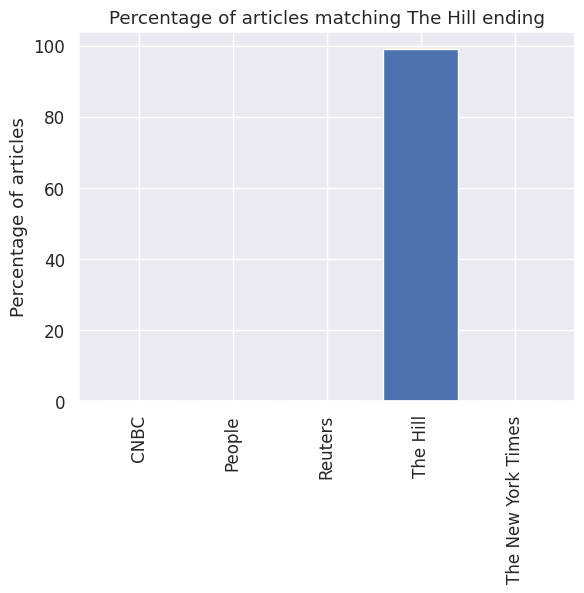

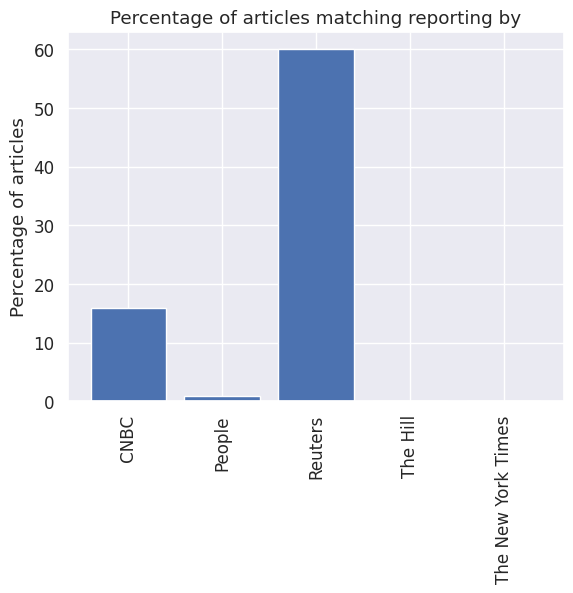

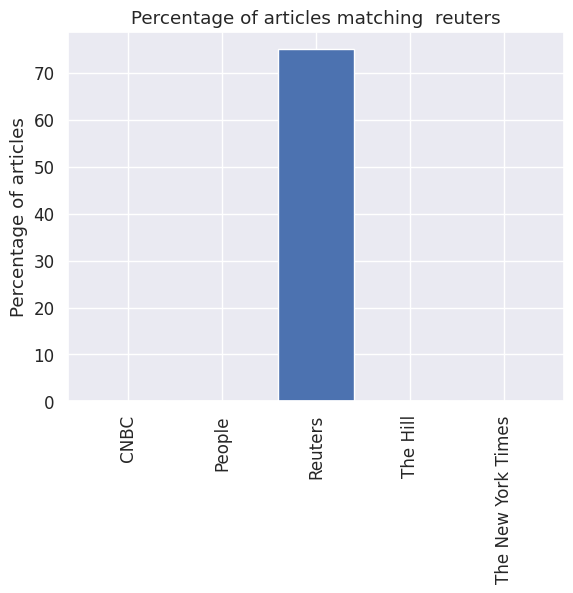

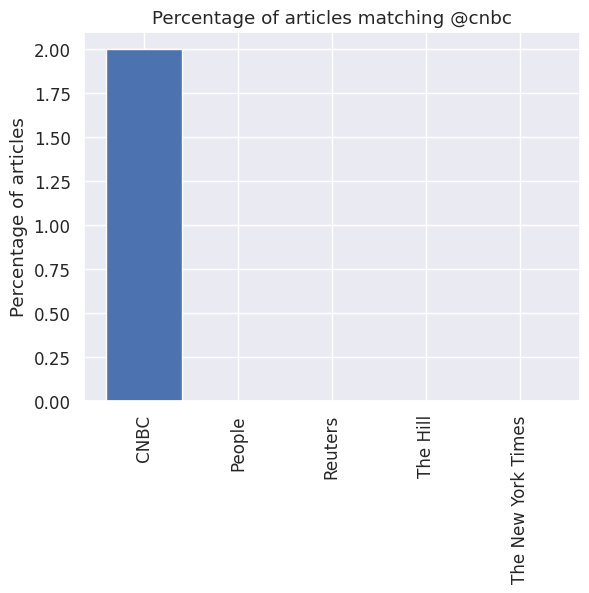

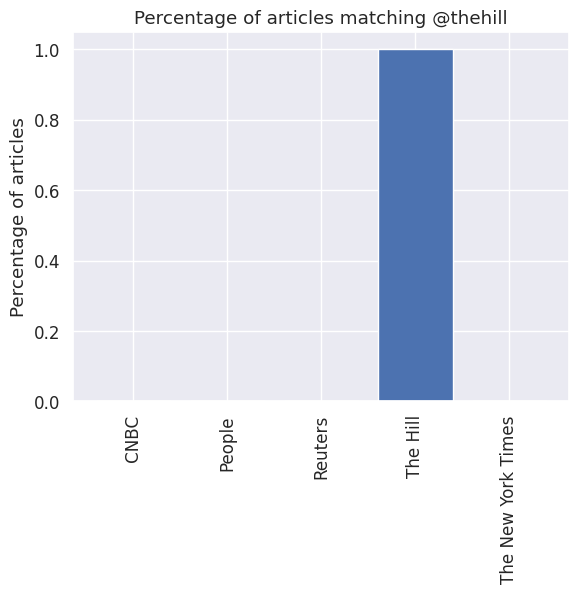

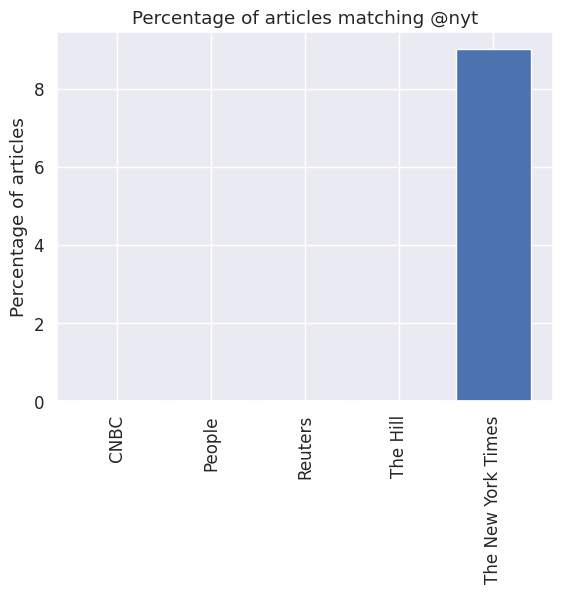

In [15]:
def remove_patterns(df: pd.DataFrame, patterns: list[re.Pattern]) -> pd.Series:
    text_series = df['article_clean_text'].copy()
    for pattern in patterns:
        text_series = text_series.str.replace(pattern, ' ', regex=True)
    return text_series

patterns= (
    re.compile(r'(view the discussion thread  )?the hill 1625 k street  nw suite 900.*'),
    re.compile(r'reporting by.*'),
    re.compile(r'^[a-z\s\d]{5,30}reuters'),
    re.compile(r'@cnbc'),
    re.compile(r'@thehill'),
    re.compile(r'@nyt\w*'))


visualize_matches(patterns[0], df_top_5, 'The Hill ending')
visualize_matches(patterns[1], df_top_5, 'reporting by')
visualize_matches(patterns[2], df_top_5, ' reuters')
visualize_matches(patterns[3], df_top_5, '@cnbc')
visualize_matches(patterns[4], df_top_5, '@thehill')
visualize_matches(patterns[5], df_top_5, '@nyt')

df_top_5.loc[:, 'article_clean_text_filtered'] = remove_patterns(df_top_5, patterns)


## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

In [16]:
# TODO: Realice una visualización que permita comparar las palabras más frecuentes
# de cada uno de los cinco medios de prensa.
# - ¿Encuentra algún problema en los resultados?

grouped_top_5 = df_top_5.groupby('publication')
df_words_list = []
for publication, group in grouped_top_5:
    articles = group['article_clean_text_filtered'].dropna().tolist()
    words = ' '.join(articles).split(' ')
    unique_words, counts = np.unique(words, return_counts=True)
    df_words = pd.DataFrame({
        'word': unique_words,
        'count': counts,
        'publication': publication
    })
    df_words = df_words[df_words['word'] != ' ']
    df_words = df_words[df_words['word'] != '']
    df_words_list.append(df_words)




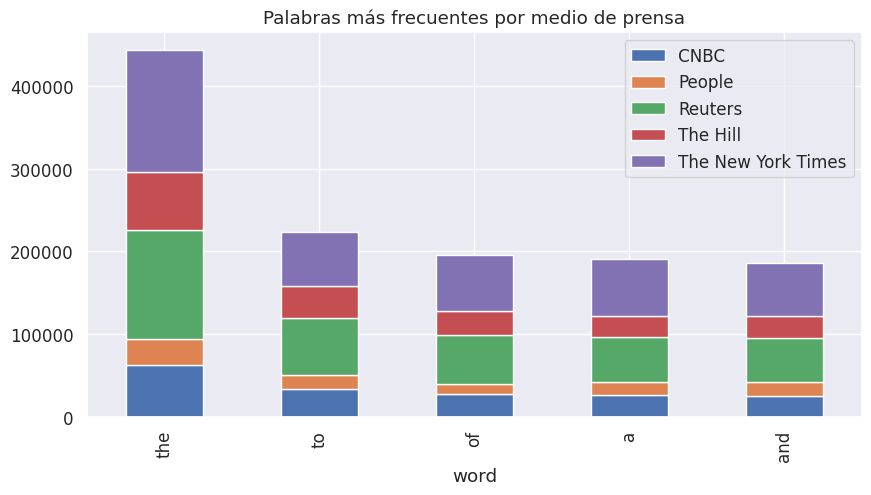

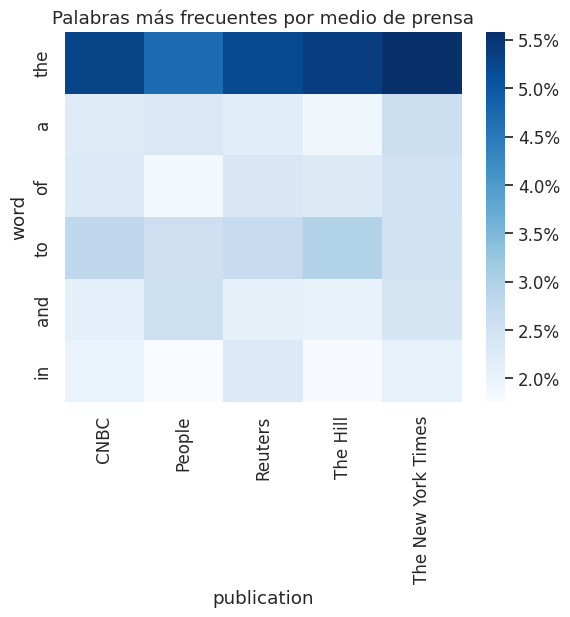

In [42]:
N = 5

df_words_all = pd.concat(df_words_list)
df_words_all = df_words_all.sort_values('count', ascending=False)
# display(df_words_all.head())

def plot_top_words(df: pd.DataFrame, title: str, N: int = 20, name: str = 'most_common_words') -> None:
    df_pivot = df.pivot(index='word', columns='publication', values='count').fillna(0)
    df_pivot['total'] = df_pivot.sum(axis=1)
    df_pivot.sort_values('total', ascending=False, inplace=True)
    # display(df.head())
    df_pivot.head(N)[df_pivot.columns[:-1]].plot(
        kind='bar', 
        title=title, 
        stacked=True, 
        figsize=(10, 5),
        )
    plt.legend()
    plt.savefig(figures_path / f'{name}.png')
    plt.show()

    df_pivot_norm = 100*df_pivot / df_pivot.sum(axis=0)

    most_frequent_words = set()
    for publication, group in df.groupby('publication'):
        top_words = group.sort_values('count', ascending=False).head(N)
        most_frequent_words.update(top_words['word'].tolist())
    most_frequent_words = list(most_frequent_words)
    sns.heatmap(
        df_pivot_norm.loc[most_frequent_words, df_pivot_norm.columns[:-1]], 
        cmap='Blues',
        yticklabels=True,
        cbar_kws={'format': '%.1f%%'})
    # plt.tight_layout()
    plt.title(title)
    plt.savefig(figures_path / f'{name}_heatmap.png', bbox_inches='tight')
    plt.show()

plot_top_words(df_words_all, 'Palabras más frecuentes por medio de prensa', N, 'most_common_words')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mariano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


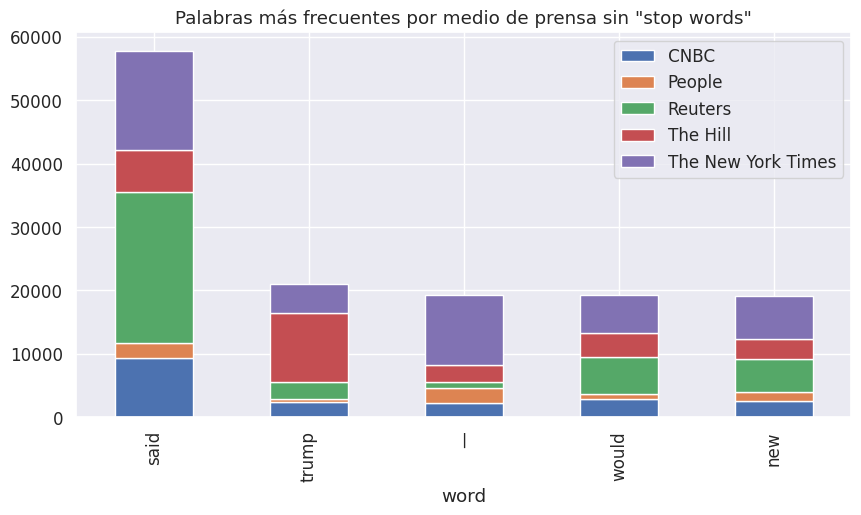

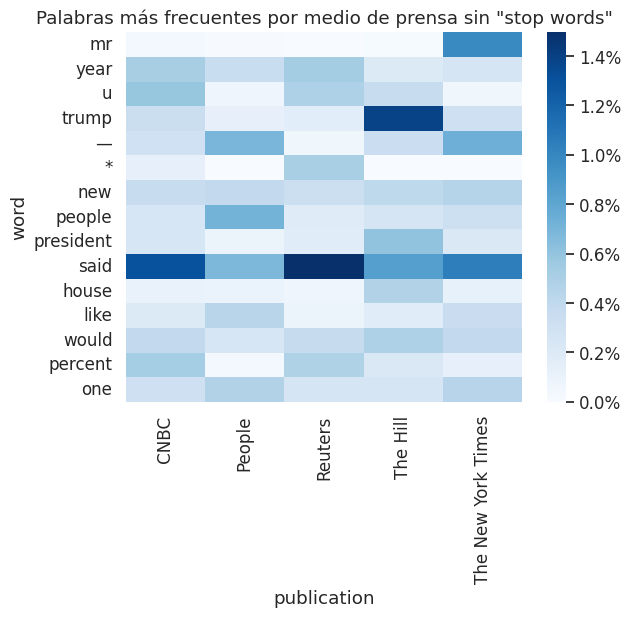

In [43]:
# Filtrando stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df_words_all = df_words_all[~df_words_all['word'].isin(stop_words)]
plot_top_words(
    df_words_all, 
    'Palabras más frecuentes por medio de prensa sin "stop words"', 
N, 'most_common_words_no_stopwords')



## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

publication
Reuters               9431
The New York Times    2840
CNBC                  2449
The Hill              2349
People                1528
Name: count, dtype: int64

publication
The New York Times    2643680
Reuters               2535966
The Hill              1299044
CNBC                  1198280
People                 649099
Name: count, dtype: int64

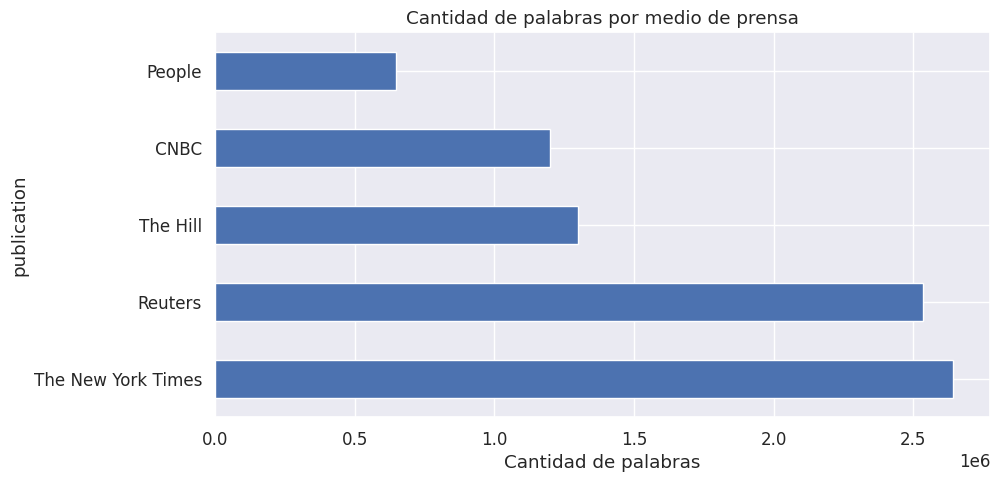

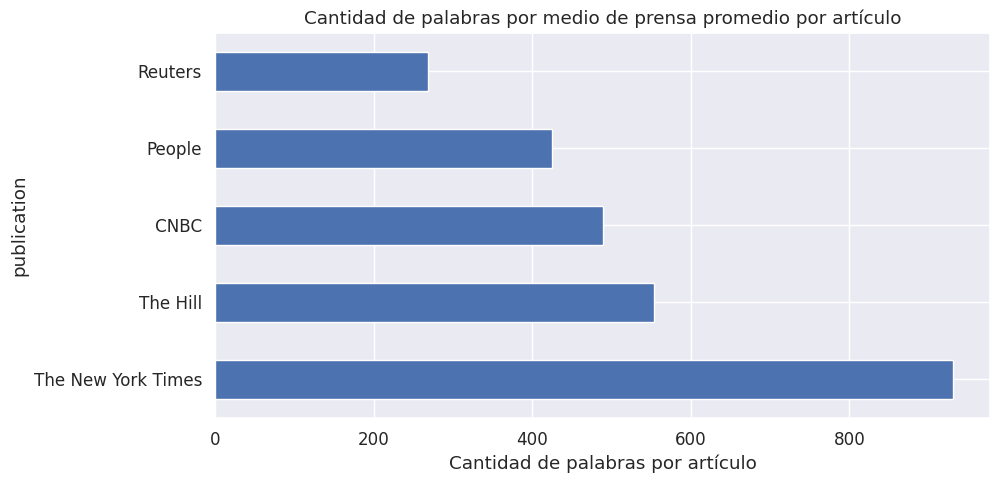

In [ ]:
# TODO: Busque los medios con mayor cantidad de palabras
num_articles_by_publication = df_top_5['publication'].value_counts()
display(num_articles_by_publication.head())

counts_by_publication = df_words_all.groupby('publication')['count'].sum()
counts_by_publication.sort_values(inplace=True, ascending=False)
display(counts_by_publication)
counts_by_publication.plot(kind='barh', title='Cantidad de palabras por medio de prensa', figsize=(10, 5))
plt.xlabel('Cantidad de palabras')
plt.savefig(figures_path / 'word_count_by_publication.png')
plt.show()

count_by_publication_normalized = counts_by_publication / num_articles_by_publication
count_by_publication_normalized.sort_values(inplace=True, ascending=False)
count_by_publication_normalized.plot(kind='barh', title='Cantidad de palabras por medio de prensa promedio por artículo', figsize=(10, 5))
plt.xlabel('Cantidad de palabras por artículo')
plt.savefig(figures_path / 'word_count_by_publication_normalized.png')
plt.show()


## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

array([[3810,    0,   44,    0, 2830],
       [  54,    0,   19,    0, 4724],
       [ 960,    0, 1707,    0, 1765],
       [ 123,    0,   20,    0, 2006],
       [   7,    0,    5,    0, 2526]])

['Reuters' 'The New York Times' 'CNBC' 'The Hill' 'People']


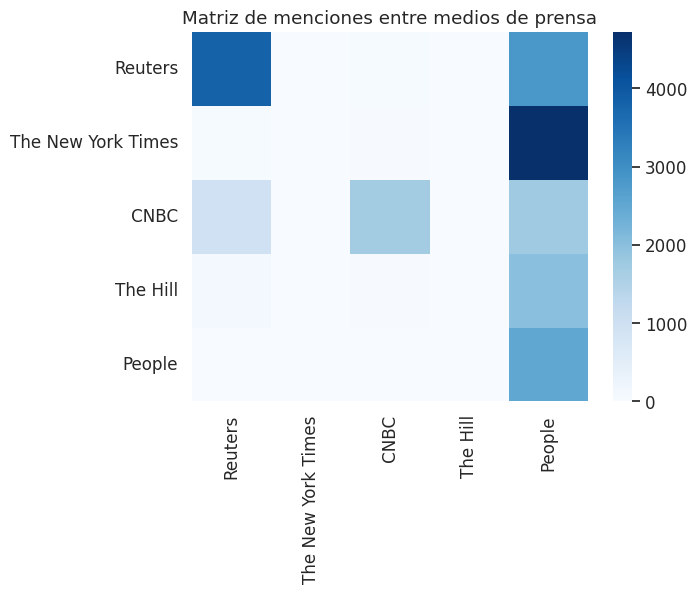

In [49]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# mentions_matrix = ...
mentions_matrix = np.zeros((5, 5), dtype=int)
for i, pub_i in enumerate(top_5):
    df_pub_i = df_words_all[df_words_all['publication'] == pub_i]
    for j, pub_j in enumerate(top_5):
        mentions_matrix[i, j] = df_pub_i[df_pub_i['word'] == pub_j.lower()]['count'].sum()

display(mentions_matrix)
print(top_5)
sns.heatmap(mentions_matrix, 
xticklabels=top_5, yticklabels=top_5, cmap='Blues',
annot=False)
plt.title('Matriz de menciones entre medios de prensa')
plt.savefig(figures_path / 'mentions_matrix.png', bbox_inches='tight')
plt.show()



[5.03259949195597, 1.0465707027942421, 3.995342929720576, 1.0571549534292972, 1.0201100762066047, 6.0, 2.0160880609652834, 2.806731583403895, 2.868120237087214, 1.130186282811177, 1.0211685012701102, 3.1232006773920404, 1.0074089754445386, 1.0052921253175275, 3.673581710414903]


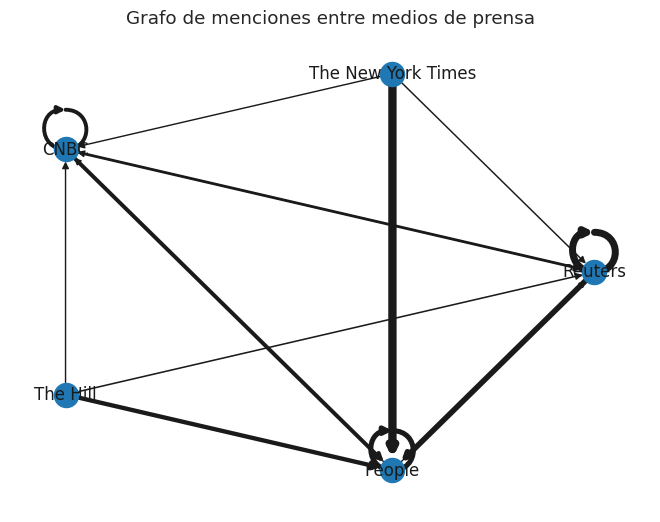

In [38]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.
graph = nx.from_numpy_array(mentions_matrix, create_using=nx.DiGraph)
weights = [graph[i][j]['weight'] for i, j in graph.edges()]
max_weight = max(weights)
edge_widths = [1 + 5 * (w / max_weight) for w in weights]
print(edge_widths)
nx.draw(
    G=graph, 
    with_labels=True, 
    labels={i: pub for i, pub in enumerate(top_5)},
    width=edge_widths,
    pos=nx.circular_layout(graph))
plt.title('Grafo de menciones entre medios de prensa')
plt.savefig(figures_path /  'mentions_graph.png', bbox_inches='tight')
plt.show()

## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*